<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/2_6_3_SMV_NoLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Support Vector Machines: Sesión n°2**

### El método de Máquinas de Vectores de Soporte (SVM) se basa en encontrar el hiperplano que genera la partición óptima del espacio maximizando el margen entre clases. Aunque inicialmente esto limita su uso a problemas linealmente separables, esta restricción se supera mediante el mapeo de los datos a un espacio de mayor dimensión, transformando problemas complejos en tareas linealmente separables.

# **1. Preparación y el Caso Lineal**

In [ ]:
#Importando las librerías necesarias
import sklearn.datasets
import sklearn.svm # Support vector machines
import sklearn.metrics
import sklearn.gaussian_process # Kernel de transformación del espacio
import sklearn.preprocessing
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import scipy

### **Nota:** Para demostrar el funcionamiento "base" de las Support Vector Machines generaremos un conjunto de datos sintético linealmente separable. Utilizaremos la función make_blobs de la librería sklearn para generar nubes de puntos controladas. El objetivo es crear dos grupos de datos que estén lo suficientemente mezclados para que el desafío de clasificación sea interesante.

### Detalle de las variables:
Para construir nuestro conjunto de datos, emplearemos los siguientes parámetros:
*   **n_samples = 200:** Generamos 200 registros en total.
*   **n_features = 2:** Cada dato tiene solo dos características (X e Y).
*   **centers = 2:** Definimos que existen dos grupos o clases (clase 0 y clase 1). Tenemos un problema de clasificación binaria.
*   **cluster_std =** 5: Este es el parámetro de "ruido" o dispersión. Al usar un valor alto (5), los grupos no estarán perfectamente separados, sino que se solaparán un poco, obligando al modelo SVM a buscar el mejor margen posible.
*   **random_state = 11:** Es una "semilla" de aleatoriedad. Nos asegura que, cada vez que corramos el código, obtendremos exactamente los mismos puntos, permitiendo que nuestras conclusiones sean replicables.











In [ ]:
blobs_features, blobs_label = sklearn.datasets.make_blobs(
    n_samples = 200,
    n_features = 2,
    centers=2,
    cluster_std = 5,
    random_state=11
)

#**2. División del conjunto de datos (Train/Test Split)**

A continuación,separamos el conjunto en subconjuntos de entrenamiento y prueba.

*   **blobs_features / blobs_label:** Son los datos originales y sus etiquetas que creamos en el paso anterior.
*   **test_size=0.33:** Indica que el 33% de los datos se reservarán para el examen (prueba) y el 67% restante se usará para el aprendizaje (entrenamiento).
*   **random_state=11:** Al igual que antes, esto garantiza que la división sea siempre la misma cada vez que ejecutemos el notebook, manteniendo la consistencia de nuestros resultados.

In [ ]:
(
    blobs_features_train,
    blobs_features_test,
    blobs_label_train,
    blobs_label_test
) = sklearn.model_selection.train_test_split(
    blobs_features,
    blobs_label,
    test_size=0.33,
    random_state=11
)

# **3. Visualización de los Datos (Train vs Test)**

**Nota:** Antes de aplicar el algoritmo, debemos analizar visualmente la complejidad del problema. El gráfico resultante nos muestra cómo están distribuidos nuestros datos en el espacio bidimensional.

1. **Separabilidad Lineal:** Observamos que los puntos morados (Clase 0) están mayoritariamente en la parte inferior izquierda, mientras que los naranjas (Clase 1) están hacia la superior derecha.
2. **Zona de Conflicto (Solapamiento):** Podemos notar que en el centro hay círculos y cruces de ambos colores mezclados. Esto se debe al parámetro cluster_std = 5 que usamos al principio.  

    * **Interpretación:** No existe una línea "perfecta" que separe ambos grupos sin cometer errores. El SVM tendrá que encontrar la línea que minimice esos errores y maximice el margen.

3. **Representatividad del Test:** Las cruces (x) están distribuidas en las mismas zonas que los círculos. Esto indica que nuestra división de datos fue exitosa: el "examen" (test) tiene el mismo nivel de dificultad y la misma distribución que los "ejercicios de estudio" (entrenamiento).


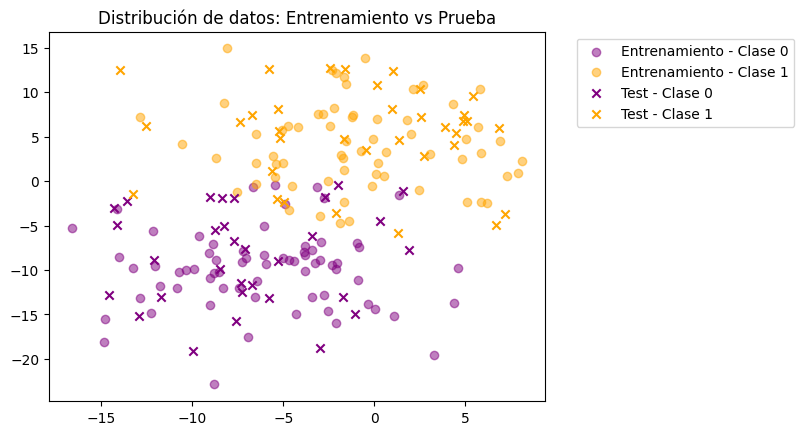

In [ ]:
#Graficamos el entrenamiento separando por colores para la leyenda
plt.scatter(x = blobs_features_train[blobs_label_train==0, 0],
            y = blobs_features_train[blobs_label_train==0, 1],
            c = 'purple', label = "Entrenamiento - Clase 0", alpha=0.5)

plt.scatter(x = blobs_features_train[blobs_label_train==1, 0],
            y = blobs_features_train[blobs_label_train==1, 1],
            c = 'orange', label = "Entrenamiento - Clase 1", alpha=0.5)

#Graficamos el test con cruces
plt.scatter(x = blobs_features_test[blobs_label_test==0, 0],
            y = blobs_features_test[blobs_label_test==0, 1],
            c = 'purple', marker = "x", label = "Test - Clase 0")

plt.scatter(x = blobs_features_test[blobs_label_test==1, 0],
            y = blobs_features_test[blobs_label_test==1, 1],
            c = 'orange', marker = "x", label = "Test - Clase 1")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Distribución de datos: Entrenamiento vs Prueba")
plt.show()

# **4. Entrenamiento del Modelo (Kernel Lineal)**

Evaluaremos el desempeño de este método con un kernel linea, lo que es lo mismo que utilizar directamente SVM sin modificar el espacio.
Lo que buscamos es la línea que maximice el margen (la distancia entre los puntos más cercanos de cada bando).

* **Identificar los Vectores de Soporte:** puntos clave que tocan los bordes del margen y definen la posición de la frontera.

In [ ]:
svm_linear = sklearn.svm.SVC(kernel="linear")
svm_linear.fit(blobs_features_train, blobs_label_train)

SVC(kernel='linear')

#**5. Visualización de la Frontera de Decisión Lineal**

Al entrenar nuestra SVM con kernel lineal ajustaremos los coeficientes asociados a la hiperplano que separa las clases.

Cuando ejecutamos el entrenamiento, el SVM busca los valores óptimos para una ecuación lineal. Los resultados para este ejemplo, son los siguientes:

svm_linear.coef_ (W - Pesos): Representan la importancia de cada característica.

**El primer valor (0.1009):** Acompaña a la Característica 1 (Eje X).

El segundo valor (0.3122) acompaña a la Característica 2 (Eje Y).

**Interpretación:** Como el segundo valor es más grande, la Característica 2 tiene más peso en la decisión final del modelo.

**svm_linear.intercept_ (b - Intercepto/Sesgo):** Es el valor que desplaza la línea respecto al origen (0,0).

In [ ]:
svm_linear.coef_

array([[0.10097214, 0.31220573]])

In [ ]:
svm_linear.intercept_

array([1.40429114])

En cuanto a la ecuación matemática: El modelo decide la clase de un punto usando la fórmula:$$f(x) = (w_1 \cdot x_1) + (w_2 \cdot x_2) + b$$Sustituyendo tus valores:$$f(x) = (0.10 \cdot \text{X}) + (0.31 \cdot \text{Y}) + 1.40$$


Donde $w$ son los coeficientes ajustados y $b$ es el intercepto

#**6. Cálculo manual de la Distancia al Hiperplano**

El siguiente paso que realizaremos, será aplicar manualmente la ecuación del hiperplano:$$f(x) = X \cdot W^T + b$$

* **np.dot(puntos, pesos):** El modelo multiplica las características del punto por la importancia que le asignó a cada una. Es como un promedio ponderado que nos dice qué tan "parecido" es el punto a una clase o a la otra.

* **intercepto:** Es el punto de equilibrio. Si el resultado anterior no supera este valor umbral, el punto se queda de un lado de la frontera; si lo supera, pasa al otro.

In [ ]:
np.dot(
    blobs_features_test,
    svm_linear.coef_[0]
) + svm_linear.intercept_

array([ 1.19829619,  0.03213911,  3.53524277,  0.58821154,  2.75314431,
        3.11048161, -2.52024034,  5.14610692,  4.95782002,  1.08422087,
       -5.58098065, -0.99596509,  0.15860148,  2.70308853,  3.41169862,
        2.41118597,  4.01356035, -1.55281051, -2.59591921,  5.36433186,
       -4.28534379, -4.07978834,  0.54768656,  4.88432169,  2.99720841,
        0.98487866, -0.99183193,  4.01907412,  3.06464116, -3.22770938,
       -1.94818743,  4.23492146,  4.80463633, -0.07123254,  2.07256158,
       -1.18612123, -1.47030098,  1.22451357, -0.66432139, -3.27232736,
       -0.38165972, -4.74061081, -0.28477351, -3.36011109, -2.92965653,
        2.46380377,  3.68952661,  0.24258159,  2.5717767 , -2.92103308,
        4.04121248, -0.85306928,  2.62634754, -3.8463254 ,  0.07912577,
        3.88764865, -4.64849073, -2.82160889, -0.04436051,  3.90640312,
        3.95305212, -0.81310144,  5.18920144, -1.71192526,  0.02330571,
        4.77296815])

# **7. De la Distancia a la Clasificación**

Ahora, el modelo debe tomar una decisión binaria. El siguiente bloque de código simula exactamente lo que hace la función .predict() de Scikit-Learn:

1. **(...) > 0: Esta es la función de activación. Compara cada distancia:**

* Si la distancia es mayor a cero, devuelve True (está en el lado positivo).
* Si es menor o igual a cero, devuelve False (está en el lado negativo).

2. **astype(int): Convierte los valores booleanos en números enteros:**

* True se convierte en 1.
* False se convierte en 0.

In [ ]:
svm_linear_predictions = ((np.dot(
    blobs_features_test,
    svm_linear.coef_[0]
) + svm_linear.intercept_) > 0).astype(int)
svm_linear_predictions

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1])

#**8. Informe de Clasificación (Métricas de Rendimiento)**

In [ ]:
print(sklearn.metrics.classification_report(blobs_label_test,svm_linear_predictions))

              precision    recall  f1-score   support

           0       0.93      0.84      0.88        31
           1       0.87      0.94      0.90        35

    accuracy                           0.89        66
   macro avg       0.90      0.89      0.89        66
weighted avg       0.90      0.89      0.89        66



## Precisión:

* **Clase 0 (Morado) - 0.93:** De todos los puntos que el modelo predijo como morados, el 93% realmente lo eran. Es un modelo muy confiable al identificar los puntos morados.

* **Clase 1 (Naranja) - 0.87: **Aquí es un poco más bajo. Significa que hubo algunos puntos morados que el modelo "confundió" y pintó de color naranja.

## Recall:

* **Clase 0 (Morado) - 0.84:** De todos los puntos morados que existían en el test, el modelo logró encontrar al 84%. El otro 16% se le escapó (fueron clasificados erróneamente como naranjas).

* **Clase 1 (Naranja) - 0.94:** ¡Excelente! El modelo casi no dejó puntos naranjas sin identificar.

## F1-Score (0.88 y 0.90):

* Como ambos valores están cerca del 0.90, confirmamos que el modelo es equilibrado. No es mucho mejor para una clase que para la otra.

## Accuracy - 0.89:
* La exactitud revela que SVM lineal acertó 89 de cada 100 casos. Para un conjunto de datos con ruido (cluster_std=5). Podemos decir con propiedad de que este este desempeño es sobresaliente

# **9. Convirtiendo el Hiperplano en una Función Lineal**

Aunque el SVM trabaja con vectores y matrices, en un plano de dos dimensiones (2D), su frontera de decisión no es más que una línea recta. Para poder graficar esa línea manualmente, necesitamos transformarla a la forma:$$y = mx + b$$*Donde $m$ es la pendiente y $b$ es el intercepto*.<br>Desglose matemático del código:<br>El SVM define la frontera cuando la suma es cero: $w_0 \cdot x + w_1 \cdot y + intercepto = 0$.<br>Si despejamos la $y$ (que es nuestra función), obtenemos:<br>1. **Pendiente ($m$):** -1 * svm_linear.coef_[0][0] / svm_linear.coef_[0][1]. Es la relación negativa entre los dos pesos.<br>2. **Intercepto ($c$):** svm_linear.intercept_[0] / svm_linear.coef_[0][1]. Es el desplazamiento vertical.<br>**La Función linear_function(x):**<br>Esta función ahora puede recibir cualquier valor de $x$ y nos dirá exactamente por dónde pasa la línea de decisión del modelo.

In [ ]:
def linear_function(x, m = -1 * svm_linear.coef_[0][0] / svm_linear.coef_[0][1] , c = svm_linear.intercept_[0] / svm_linear.coef_[0][1]):
    return m * x - c

# **10. Preparación de las coordenadas de la frontera**

La siguiente labor es dibujar una línea recta en un gráfico, técnicamente solo necesitamos dos puntos. En este bloque, definimos los extremos de esa línea para que cruce todo nuestro gráfico de lado a lado.
Con esto ya tenemos dos puntos: (x_min, y_start) y (x_max, y_end). Al unirlos con una función de dibujo, veremos la frontera de separación que el SVM lineal construyó.

In [ ]:
decision_boundary_line_x = np.array([blobs_features_train[:,0].min(), blobs_features_train[:,0].max()])
decision_boundary_line_y = [linear_function(x) for x in decision_boundary_line_x]

#**11. Los puntos extremos de la frontera**

In [ ]:
decision_boundary_line_y

[np.float64(0.8836303376569807), np.float64(-7.133404274104089)]

**Nota:** Estos dos números le dicen a Python: "Dibuja una línea que empiece en esta altura a la izquierda y termine en esta otra altura a la derecha"

# **12. Anatomía del Clasificador SVM**

**Importante:** En este gráfico, estamos visualizaremos los tres componentes que definen al Support Vector Machine:

* **Los Datos (Círculos y "X"):** Nuestra materia prima de entrenamiento y prueba.

* **La Frontera de Decisión (Línea Sólida):** El lugar geométrico donde el modelo decide el cambio de clase, graficado a partir de nuestra función manual.

* **Los Vectores de Soporte (Círculos con borde negro):** Graficados con svm_linear.support_vectors_. Estos son los puntos más críticos del dataset.

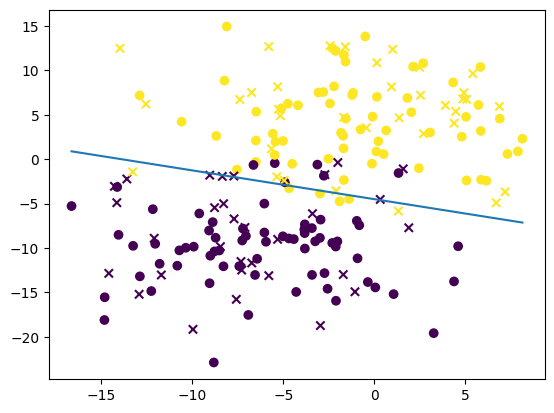

In [ ]:
plt.scatter(
    x = blobs_features_train[:,0],
    y = blobs_features_train[:,1],
    c = blobs_label_train,
    label = "traint"
)
plt.scatter(
    x = blobs_features_test[:,0],
    y = blobs_features_test[:,1],
    c = blobs_label_test,
    marker = "x",
    label = "test"
)
#plt.scatter(
    #x = svm_linear.support_vectors_[:,0],
    #y = svm_linear.support_vectors_[:,1],
    #s=100,
    #linewidth=1,
    #facecolors='none',
    #edgecolors='k'
 #)
plt.plot(
    decision_boundary_line_x,
    decision_boundary_line_y
)

#**13. Los Vectores de Soporte**

La propiedad .**support_vectors_** nos devuelve las coordenadas exactas $(x, y)$ de los puntos que están definiendo el margen.

In [ ]:
svm_linear.support_vectors_

array([[ -0.8202548 ,  -7.43661024],
       [ -2.7658451 ,  -1.865137  ],
       [-14.12891906,  -3.13240225],
       [ -6.03950732,  -5.00261901],
       [ -0.95605192,  -6.94138659],
       [ -3.12448181,  -0.6130948 ],
       [ -4.91287068,  -2.59663957],
       [ -5.46628995,  -0.44661249],
       [  1.33842425,  -1.56112525],
       [ -6.63811893,  -0.65283969],
       [ -1.37769503,  -4.48188689],
       [ -6.51164971,  -0.31659167],
       [ -4.67920661,  -3.27183191],
       [ -2.97963196,  -3.87606642],
       [ -4.50971126,  -0.52324161],
       [ -1.66526885,  -2.34654142],
       [ -7.54530061,  -1.17224827],
       [ -1.90218906,  -4.74424736],
       [ -5.46890775,   0.47562546]])

#**14. La Anatomía Completa del Clasificador SVM**

Los anillos negros son los Vectores de Soporte. El nombre del algoritmo viene precisamente de ellos. Estos puntos son los "pilares" que sostienen la frontera.

Si eliminamos cualquier punto que no tenga un anillo negro, la línea de decisión no se movería.

Estos puntos son los únicos que el modelo "recuerda" para definir el margen máximo entre las clases.

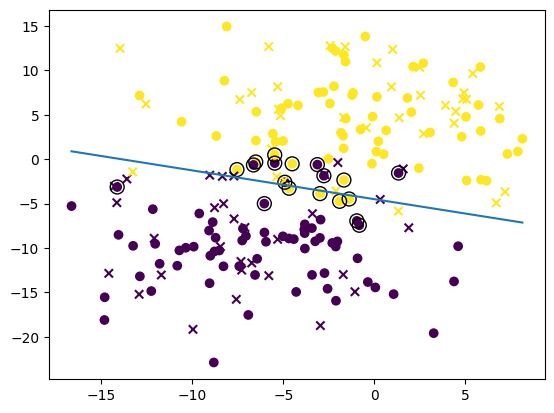

In [ ]:
plt.scatter(
    x = blobs_features_train[:,0],
    y = blobs_features_train[:,1],
    c = blobs_label_train,
    label = "traint"
)
plt.scatter(
    x = blobs_features_test[:,0],
    y = blobs_features_test[:,1],
    c = blobs_label_test,
    marker = "x",
    label = "test"
)
plt.scatter(
    x = svm_linear.support_vectors_[:,0],
    y = svm_linear.support_vectors_[:,1],
    s=100,
    linewidth=1,
    facecolors='none',
    edgecolors='k'
)
plt.plot(
    decision_boundary_line_x,
    decision_boundary_line_y
)

#**15. Creación de la Superficie de Decisión**

Estas funciones transforman las predicciones matemáticas en el mapa de colores (morado y naranja) que vemos detrás de los puntos.

In [ ]:
#Funciones para mostrar los umbrales de SVM sobre nuestros datos
def make_meshgrid(x, y, h=.02):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

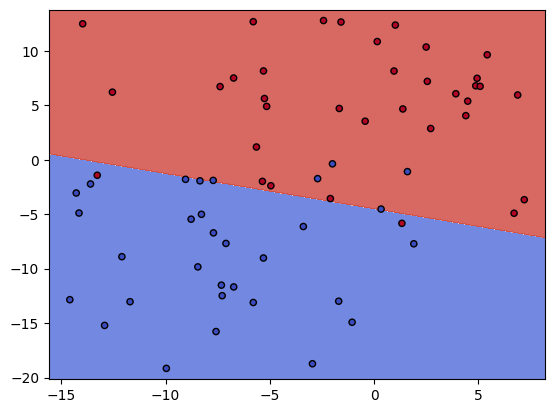

In [ ]:
fig, ax = plt.subplots()
X0, X1 = blobs_features_test[:,0], blobs_features_test[:,1]
xx, yy = make_meshgrid(X0, X1)
plot_contours(ax, svm_linear, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax.scatter(X0, X1, c=blobs_label_test, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
plt.show()

Generaremos otro conjunto de datos sintético que no es linealmente separable.

#**16. El Desafío de los Datos No Lineale**s

Utilizando la función make_gaussian_quantiles, generamos un dataset con una estructura radicalmente distinta. Esta nos permitirá trabajar con SVM pero con datos que no son posibles de separar linealmente

In [ ]:
circles_features, circles_label = sklearn.datasets.make_gaussian_quantiles(n_features=2, n_classes=2, n_samples=200, mean=(0,0), random_state = 12)

In [ ]:
(
    circles_features_train,
    circles_features_test,
    circles_label_train,
    circles_label_test
) = sklearn.model_selection.train_test_split(
    circles_features,
    circles_label,
    test_size=0.33,
    random_state=11
)

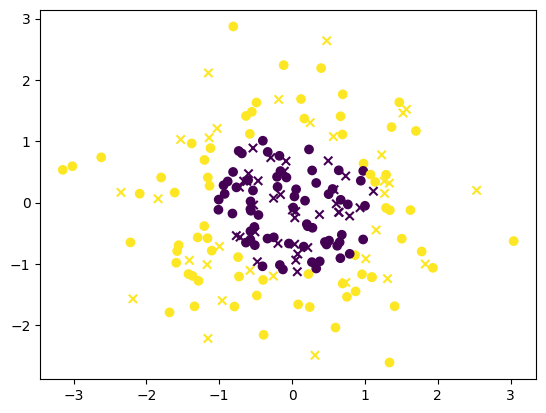

In [ ]:
plt.scatter(
    x = circles_features_train[:,0],
    y = circles_features_train[:,1],
    c = circles_label_train,
    label = "train"
)
plt.scatter(
    x = circles_features_test[:,0],
    y = circles_features_test[:,1],
    c = circles_label_test,
    marker = "x",
    label = "test"
)

#**17. Cuando la línea recta no es suficiente**

In [ ]:
svm_linear_2 = sklearn.svm.SVC(kernel="linear")
svm_linear_2.fit(circles_features_train, circles_label_train)

SVC(kernel='linear')

**¿Por qué falla el Kernel Lineal aquí?**
<br>
* **Incompatibilidad Geométrica:** El SVM lineal solo puede generar un hiperplano (una línea en 2D). Por su propia naturaleza, una línea solo puede dividir el espacio en dos mitades: "lo que está a la izquierda" y "lo que está a la derecha" (o arriba/abajo).<br><br>
* **Estructura de los Datos:** Nuestros datos no están a la izquierda o derecha; están dentro o fuera. Para separar un círculo de otro, necesitaríamos una frontera circular, algo que una función lineal **($y = mx + b$)** simplemente no puede construir.

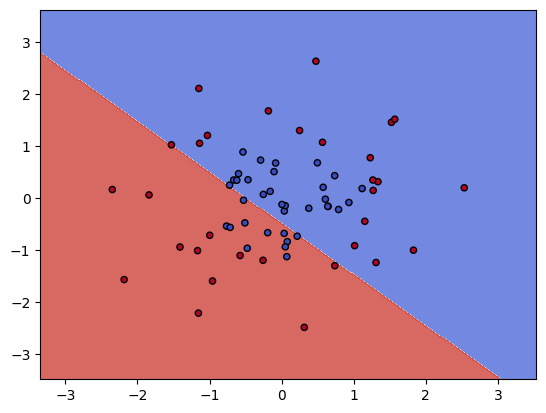

In [ ]:
fig, ax = plt.subplots()
X0, X1 = circles_features_test[:,0], circles_features_test[:,1]
xx, yy = make_meshgrid(X0, X1)
plot_contours(ax, svm_linear_2, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax.scatter(X0, X1, c=circles_label_test, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
plt.show()

#**18. Análisis de la "Derrota" del Modelo Lineal**

In [ ]:
print(sklearn.metrics.classification_report(circles_label_test, svm_linear_2.predict(circles_features_test)))

              precision    recall  f1-score   support

           0       0.56      0.69      0.62        35
           1       0.52      0.39      0.44        31

    accuracy                           0.55        66
   macro avg       0.54      0.54      0.53        66
weighted avg       0.54      0.55      0.54        66



#**19. El "Truco" del Kernel**

Como vimos que una línea recta en un plano 2D no puede separar los círculos, vamos a aplicar una idea revolucionaria: Si el problema no tiene solución en 2D, cambiemos de dimensión.

* **scipy.spatial.distance.euclidean:** Calculamos qué tan lejos está cada punto del centro (0,0).

* **np.hstack:** Añadimos esa distancia como una nueva columna en nuestros datos.

**La lógica detrás de la nueva variable:**

* Los puntos de la Clase 0 (el círculo interno) tendrán distancias pequeñas.

* Los puntos de la Clase 1 (el anillo externo) tendrán distancias grandes.

In [ ]:
distance_to_center_train = np.apply_along_axis(lambda x: scipy.spatial.distance.euclidean(x,[0,0]), 1, circles_features_train)
distance_to_center_train

array([0.669112  , 0.78403294, 0.73387031, 1.40731504, 0.50342035,
       1.55755523, 0.10635932, 0.85987943, 0.73689434, 1.70375148,
       0.18060842, 0.3258498 , 1.84316882, 2.12128294, 2.92829122,
       0.78286192, 0.46935441, 1.16521296, 0.57182574, 1.02942199,
       0.83123053, 0.86111509, 1.80919842, 2.20057727, 1.29741386,
       0.67565487, 2.31107419, 1.21654101, 1.16956126, 1.11667294,
       1.11397015, 1.70955951, 1.66052737, 2.72175215, 1.26224654,
       0.65172269, 1.54870237, 1.51171766, 1.38967534, 1.41308594,
       1.29228153, 2.20575783, 2.22939323, 1.36874634, 1.10558684,
       0.94868777, 1.35198048, 1.14960224, 2.15612859, 1.58862188,
       1.1890895 , 0.4403934 , 1.70376068, 1.63488484, 3.19258534,
       1.68887064, 1.00672735, 0.91730273, 0.83740273, 0.80316937,
       1.34790252, 1.8394262 , 1.057719  , 0.404081  , 0.53879141,
       1.14513319, 0.70670042, 1.09572776, 1.08618108, 0.93659084,
       1.83683582, 0.98219526, 0.82985212, 0.08161413, 1.68239

In [ ]:
distance_to_center_test = np.apply_along_axis(lambda x: scipy.spatial.distance.euclidean(x,[0,0]), 1, circles_features_test)

In [ ]:
circles_features_train_with_distances = np.hstack([circles_features_train, np.expand_dims(distance_to_center_train, axis = 1)])
circles_features_train_with_distances

array([[ 0.66750106,  0.04640264,  0.669112  ],
       [ 0.45088923, -0.64140982,  0.78403294],
       [ 0.1597877 , -0.71626359,  0.73387031],
       [-0.72880073, -1.20390412,  1.40731504],
       [-0.46139494, -0.20136227,  0.50342035],
       [ 0.6660776 ,  1.40794848,  1.55755523],
       [ 0.03250208,  0.10127152,  0.10635932],
       [ 0.68255535, -0.52298262,  0.85987943],
       [-0.57132789, -0.46540059,  0.73689434],
       [-0.48882101,  1.63212228,  1.70375148],
       [ 0.17774987,  0.03200602,  0.18060842],
       [-0.19932734,  0.25777259,  0.3258498 ],
       [-1.79682746,  0.41070962,  1.84316882],
       [ 0.59590861, -2.03586204,  2.12128294],
       [ 1.33749137, -2.60499641,  2.92829122],
       [-0.17331676,  0.76343571,  0.78286192],
       [-0.20630936,  0.42158037,  0.46935441],
       [-1.13246885,  0.274291  ,  1.16521296],
       [-0.53648126,  0.19792052,  0.57182574],
       [ 0.38011359, -0.95667303,  1.02942199],
       [-0.57181673, -0.60329911,  0.831

In [ ]:
circles_features_test_with_distances = np.hstack([circles_features_test, np.expand_dims(distance_to_center_test, axis = 1)])

#**20. Visualización en 3D (La Elevación de los Datos)**

In [ ]:
px.scatter_3d(x = circles_features_train_with_distances[:,0],
           y = circles_features_train_with_distances[:,1],
           z = circles_features_train_with_distances[:,2],
              color = circles_label_train)


Si ajustamos el modelo sobre este conjunto de datos con la variable extra vemos que funciona mucho mejor.

In [ ]:
svm_linear_3 = sklearn.svm.SVC(kernel="linear")
svm_linear_3.fit(circles_features_train_with_distances, circles_label_train)

SVC(kernel='linear')

In [ ]:
print(sklearn.metrics.classification_report(circles_label_test, svm_linear_3.predict(circles_features_test_with_distances)))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        35
           1       1.00      0.90      0.95        31

    accuracy                           0.95        66
   macro avg       0.96      0.95      0.95        66
weighted avg       0.96      0.95      0.95        66



#**21. El Kernel RBF (Radial Basis Function)**

En lugar de crear variables manualmente, los científicos de datos utilizan Kernels. El Kernel RBF es el más popular porque es increíblemente flexible.

**¿Qué está pasando en este código?**

* **sklearn.gaussian_process.kernels.RBF():** Definimos el núcleo gaussiano. Imagina que este kernel coloca una "colina" de probabilidad sobre cada punto.

* **rbf(circles_features_train):** Calculamos la similitud de cada punto con los demás. El resultado es una medida de "cercanía" matemática.

* **z = rbf_train:** Al igual que hicimos con la distancia, usamos el resultado del Kernel como nuestra tercera dimensión.

**Nota:** Mientras que nuestra distancia manual era una línea recta hacia arriba, el RBF crea una curva de campana (Gaussiana). Los puntos que están cerca de otros puntos de su misma clase obtienen valores altos, "elevándose" en el gráfico 3D de una manera más sofisticada.

In [ ]:
rbf = sklearn.gaussian_process.kernels.RBF()

# **22. Generamos la característica sintética.**

In [ ]:
rbf_train = rbf(circles_features_train)[0]
rbf_train

array([1.00000000e+00, 7.71049021e-01, 6.57233243e-01, 1.72654494e-01,
       5.12785932e-01, 3.95776920e-01, 8.16182623e-01, 8.50259994e-01,
       4.07253332e-01, 1.45760014e-01, 8.86892280e-01, 6.71638948e-01,
       4.49224634e-02, 1.14123302e-01, 2.37683132e-02, 5.43049114e-01,
       6.36257773e-01, 1.92836540e-01, 4.78899005e-01, 5.80203615e-01,
       3.75682663e-01, 3.79803844e-01, 6.22453112e-02, 2.04509848e-01,
       1.54544507e-01, 4.94299650e-01, 1.22123895e-02, 6.53028353e-01,
       7.99770094e-01, 2.73279572e-01, 3.12449507e-01, 2.85462739e-01,
       1.97161506e-01, 3.54561489e-03, 2.57848959e-01, 4.49253525e-01,
       1.68681872e-01, 4.58446346e-01, 1.40861278e-01, 1.20906437e-01,
       8.17003963e-01, 2.42828513e-01, 9.62282275e-02, 7.57417232e-01,
       8.53088702e-01, 2.87213190e-01, 1.48063255e-01, 6.73335523e-01,
       2.95772811e-02, 1.52740037e-01, 8.57133903e-01, 8.22697095e-01,
       6.41668340e-02, 4.12365687e-01, 6.13562658e-04, 3.21398754e-01,
      

# **23. La Función de Decisión en el Espacio RBF**

Para entender cómo el SVM separa los círculos, visualizamos la **Función de Decisión.** <br><br>
* El eje Z muestra la magnitud con la que el Kernel RBF separa las clases.<br>

* Los valores positivos pertenecen a una clase y los negativos a la otra.<br>
* El "plano de corte" se sitúa en $Z=0$. Aquí es donde la linealidad del SVM vuelve a aparecer en una dimensión superior.

In [ ]:
#Entrenamos el SVM con el Kernel RBF directamente
svm_rbf = sklearn.svm.SVC(kernel="rbf", gamma='auto')
svm_rbf.fit(circles_features_train, circles_label_train)

#Obtenemos la "distancia" de cada punto al hiperplano en el espacio transformado
z_rbf = svm_rbf.decision_function(circles_features_train)

#Graficamos en 3D
px.scatter_3d(
    x = circles_features_train[:,0],
    y = circles_features_train[:,1],
    z = z_rbf,
    color = circles_label_train,
    title = "Separación utilizando el Kernel RBF (Decision Function)"
)

# **24. El Triunfo del Kernel RBF en 2D**

Al cambiar el parámetro a kernel="rbf", el modelo ha dejado de intentar trazar una línea recta y ha generado una frontera de decisión circular.

* **La "Burbuja" de Decisión:** El color del fondo ahora envuelve perfectamente al grupo central.

* **Generalización:** Observen cómo las "X" (datos de prueba que el modelo nunca vio) caen mayoritariamente en las zonas del color correcto.

* **El efecto de la dimensión extra:** Aunque aquí vemos un círculo, recuerden que esto es simplemente la "sombra" del corte plano que vimos en el gráfico 3D.

In [ ]:
svm_rbf = sklearn.svm.SVC(kernel="rbf")
svm_rbf.fit(circles_features_train, circles_label_train)

SVC()

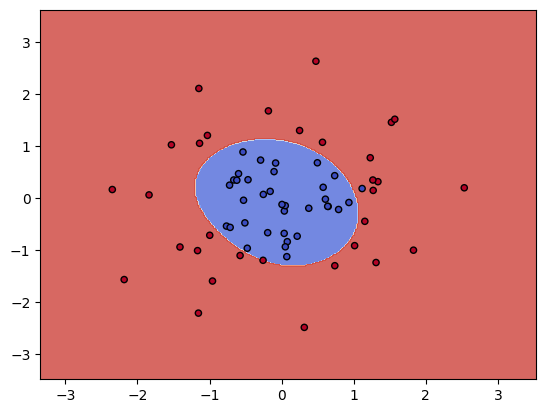

In [ ]:
fig, ax = plt.subplots()
X0, X1 = circles_features_test[:,0], circles_features_test[:,1]
xx, yy = make_meshgrid(X0, X1)
plot_contours(ax, svm_rbf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax.scatter(X0, X1, c=circles_label_test, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
plt.show()